# LAB | BMI Survey 


## Part 1: Descriptive Analysis

## Problem Description

Overweight and obesity, measured by Body Mass Index (BMI), are increasing health concerns in Denmark and globally. This project analyzes BMI data from a Danish survey to provide an overview of BMI distributions and investigate potential factors influencing BMI, such as gender, age, and fast food consumption. The analysis aims to summarize and visualize the data using descriptive statistics and graphical methods.

---

## Instructions

- Complete each section below using Python and appropriate libraries (e.g., pandas, numpy, matplotlib, seaborn).
- Provide code, tables, and figures as needed.
- Write brief explanations for your findings after each analysis step.
- Do **not** include code in your final report; code should be submitted separately as an appendix.
- Ensure all figures and tables are clearly labeled and referenced in your explanations.

---

## Q1. Data Overview

**a) Short Description of the Data**

- List all variables in the dataset.
- Classify each variable as quantitative or categorical.
- State the number of observations.
- Check for missing values.


**Instructions:**  
- Summarize the dataset variables and their types.
- Report the number of observations and any missing values.

---

In [69]:
import pandas as pd
df = pd.read_csv('data/bmi1_data.csv', sep=';')
display(df)
df.info()

,height,weight,gender,urbanity,fastfood
0,180,80,1,5,24.0
1,185,98,1,1,6.0
2,180,80,1,5,6.0
3,168,60,0,4,24.0
4,173,83,1,5,24.0
...,...,...,...,...,...
140,162,69,0,2,6.0
141,174,73,1,5,182.5
142,170,70,0,4,6.0
143,178,56,0,5,1.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   height    145 non-null    int64  
 1   weight    145 non-null    int64  
 2   gender    145 non-null    int64  
 3   urbanity  145 non-null    int64  
 4   fastfood  145 non-null    float64
dtypes: float64(1), int64(4)
memory usage: 5.8 KB


### *Key Takeaways*

*NaNs:* The dataset does not contain any NaN values. However, there seem to be some mistakes in the "fastfood" column due to abnormally large values.
*The number of observations:* 145

*We have five variables:*

*Numerical:* "Height": int, "Weight" : int, "Fastfood" : float

*Categorical:* "Gender" : int, "Urbanity" : int

## 2. Calculating BMI

- Compute BMI for each respondent using the formula:

  $$\text{BMI} = \frac{\text{weight (kg)}}{\left[\text{height (m)}\right]^2}$$

- Add BMI as a new column to the dataset.

---


In [70]:
df['BMI'] = round(df['weight'] / ((df['height']/100) ** 2), 2)
df

,height,weight,gender,urbanity,fastfood,BMI
0,180,80,1,5,24.0,24.69
1,185,98,1,1,6.0,28.63
2,180,80,1,5,6.0,24.69
3,168,60,0,4,24.0,21.26
4,173,83,1,5,24.0,27.73
...,...,...,...,...,...,...
140,162,69,0,2,6.0,26.29
141,174,73,1,5,182.5,24.11
142,170,70,0,4,6.0,24.22
143,178,56,0,5,1.0,17.67



## 3. Empirical Distribution of BMI

**b) Density Histogram of BMI Scores**

- Plot a density histogram of BMI.
- Describe the distribution: symmetry, skewness, possible negative values, and variation.

**Instructions:**  
- Comment on the shape and spread of the BMI distribution.

---


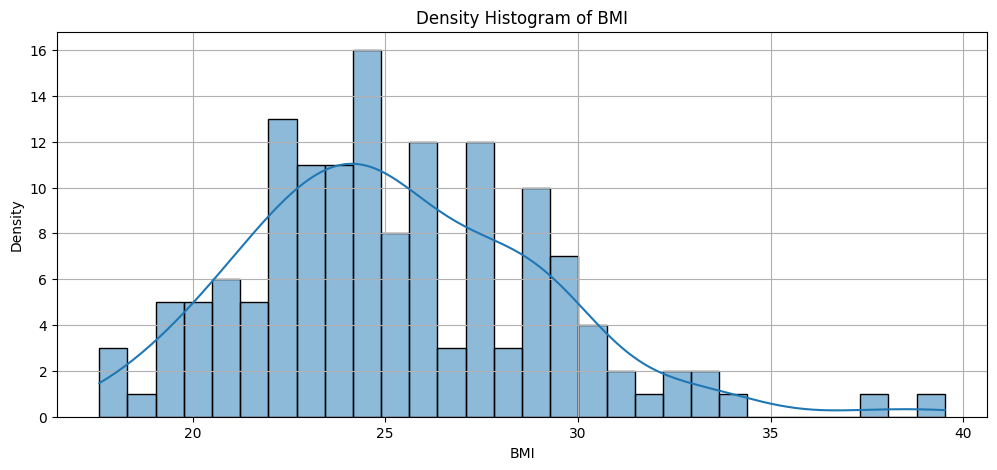

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.histplot(df["BMI"], kde=True, bins=30)

plt.xlabel("BMI")
plt.ylabel("Density")
plt.title("Density Histogram of BMI")
plt.grid(True)
plt.show()

### *Key Takeaways*

*Shape and Symmetry:* The BMI distribution is unimodal, with a peak around a BMI of 25. However, the shape is not symmetric.

*Skewness:* The distribution exhibits positive skewness (right skewed). This means there are more individuals with lower BMI values, while fewer individuals fall in the higher BMI range.

*Negative Values:* No negative values are present, as BMI cannot logically be negative.

*Variation:* BMI values range from approximately 17 to 40, with most observations concentrated between 20 and 30. The peak density suggests that the majority of individuals have a BMI around 25.



## 4. Gender Subsets

**c) Separate Density Histograms for Women and Men**

- Create subsets for women and men.
- Plot density histograms for each group.
- Compare and describe the distributions.


**Instructions:**  
- Discuss any gender differences in the BMI distributions.

---


In [72]:
df_men = df[df["gender"] == 1]
df_women = df[df["gender"] == 0]
display(df_men.head())
display(df_women.head())

,height,weight,gender,urbanity,fastfood,BMI
0,180,80,1,5,24.0,24.69
1,185,98,1,1,6.0,28.63
2,180,80,1,5,6.0,24.69
4,173,83,1,5,24.0,27.73
8,181,90,1,5,6.0,27.47


,height,weight,gender,urbanity,fastfood,BMI
3,168,60,0,4,24.0,21.26
5,161,78,0,3,6.0,30.09
6,168,82,0,2,6.0,29.05
7,166,58,0,2,24.0,21.05
9,172,52,0,1,6.0,17.58


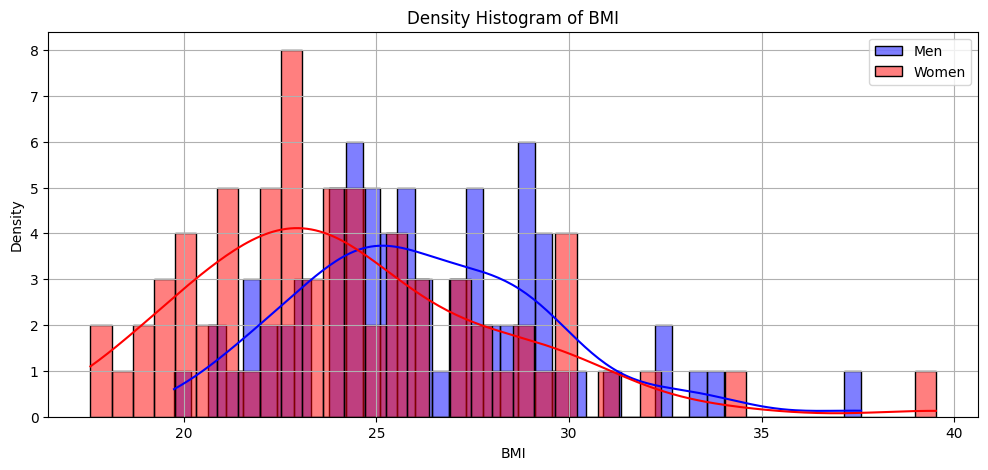

In [73]:
plt.figure(figsize=(12, 5))
sns.histplot(df_men["BMI"], kde=True, bins=40, color="blue", label = "Men", alpha = 0.5)
sns.histplot(df_women["BMI"], kde=True, bins=40, color="red", label = "Women", alpha = 0.5)

plt.xlabel("BMI")
plt.ylabel("Density")
plt.title("Density Histogram of BMI")
plt.grid(True)
plt.legend()

plt.show()

### Key Takeaways

- *Men* generally have a higher BMI on average, with a more gradual decline toward extreme values.
- *Women* tend to have lower BMI values, and their distribution tails off faster past the peak.
- Both distributions exhibit *positive skewness*, but the spread of BMI is greater for men.


## 5. Boxplot by Gender

**d) Box Plot of BMI by Gender**

- Create a box plot of BMI scores grouped by gender.
- Describe the distribution, symmetry/skewness, differences, and outliers.

**Instructions:**  
- Interpret the box plot and compare distributions.

---


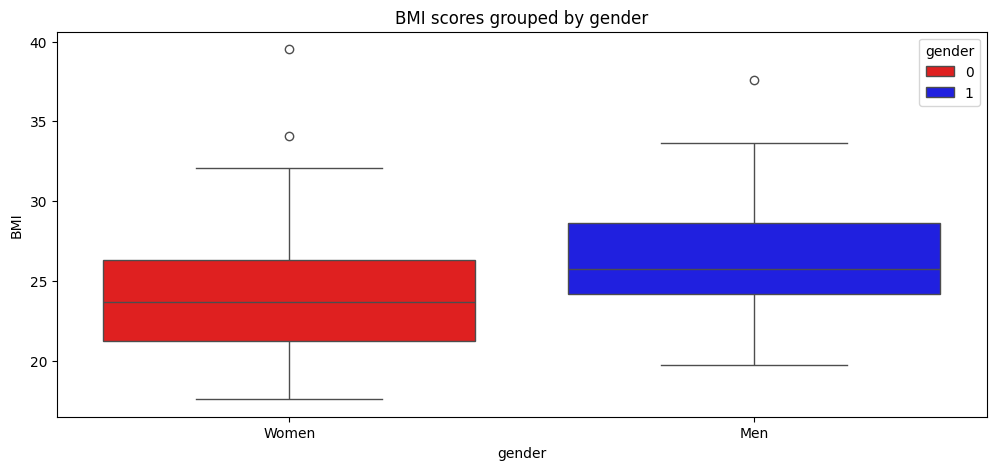

In [74]:
plt.figure(figsize=(12, 5))
sns.boxplot(x=df["gender"], y=df["BMI"], data = df, hue = "gender", palette=["red", "blue"])

plt.xticks(ticks=[0,1], labels=["Women", "Men"])
plt.xlabel("gender")
plt.ylabel("BMI")
plt.title("BMI scores grouped by gender")

plt.show()

### *Key Takeaways*

*Distribution*
The BMI scores for both **men** and **women** show a similar spread, with values generally ranging from **20 to 30**. The **median BMI** for both genders falls between **25 and 26**, indicating that most individuals have BMI scores in this range.

*Symmetry & Skewness*
- The **women's distribution** appears slightly **positively skewed** (right skewed), as indicated by the longer upper whisker and the presence of two high outliers. This suggests that while most women have BMI scores around **25**, a few have significantly higher values.
- The **men's distribution** is **more symmetric**, with whiskers of approximately equal length on both sides. Although it has one outlier above 35, the overall spread is balanced.

*Differences Between Genders*
- **Men have a slightly higher median BMI** than women.
- The **interquartile range (IQR)** for both genders is **similar**, meaning the middle 50% of BMI values are close in distribution.
- Women have a **wider range of values**, with whiskers extending slightly lower than those of men, suggesting a slightly broader spread.

*Outliers*
- **Women:** Two BMI outliers are present, both above **35**, suggesting a small group of individuals with unusually high BMI scores.
- **Men:** One outlier above **35**, indicating a similar trend but with fewer extreme values compared to women.

*Conclusion*
While both men and women have comparable BMI distributions, **women's data shows more positive skewness and variability**, with two extreme values. Men's BMI is **more symmetrically distributed**, with slightly higher central values but fewer extreme cases. 

## 6. Summary Statistics

**e) Key Summary Statistics for BMI**

- Calculate and report the following for everyone, women, and men:
  - Number of observations (n)
  - Sample mean (\(\bar{x}\))
  - Sample variance (\(s^2\))
  - Sample standard deviation (\(s\))
  - Lower quartile (Q1)
  - Median (Q2)
  - Upper quartile (Q3)

**Instructions:**  
- Present the summary statistics in a table.
- Discuss what additional insights are provided by the table compared to the box plot.

---


In [75]:
overall_stats = df["BMI"].describe()
women_stats = df_women["BMI"].describe()
men_stats = df_men["BMI"].describe()

summary_table = pd.DataFrame({
    "Metric": ["n", "Mean (x̄)", "Variance (s²)", "Std Dev (s)", "Q1", "Median (Q2)", "Q3"],
    "Overall": [df["BMI"].count(), df["BMI"].mean(), df["BMI"].var(), df["BMI"].std(), overall_stats["25%"], overall_stats["50%"], overall_stats["75%"]],
    "Women": [df_women["BMI"].count(), df_women["BMI"].mean(), df_women["BMI"].var(), df_women["BMI"].std(), women_stats["25%"], women_stats["50%"], women_stats["75%"]],
    "Men": [df_men["BMI"].count(), df_men["BMI"].mean(), df_men["BMI"].var(),df_men["BMI"].std(), men_stats["25%"], men_stats["50%"], men_stats["75%"]]
})
summary_table.iloc[1:, 1:] = summary_table.iloc[1:, 1:].round(2)
summary_table

,Metric,Overall,Women,Men
0,n,145.00,72.00,73.00
1,Mean (x̄),25.25,24.22,26.27
2,Variance (s²),14.69,16.41,11.07
3,Std Dev (s),3.83,4.05,3.33
4,Q1,22.59,21.26,24.15
5,Median (Q2),24.69,23.69,25.73
6,Q3,27.64,26.29,28.63


## Key takeaways

*Central Tendencies*
The summary table shows that **men** have a higher **mean and median BMI** (26.27 and 25.73, respectively) compared to **women** (24.22 and 23.69, respectively). This indicates that the central BMI value for men is shifted towards higher values. The **box plot visually confirms this shift**, as the **median line within the box for men is positioned higher** than that for women.

*Variation (Spread)*
The table reveals that **women have a higher variance and standard deviation** (16.41 and 4.05, respectively) compared to men (11.07 and 3.33). This suggests that BMI values for **women are more diverse**. In the **box plot**, this could be observed as longer whiskers or a greater presence of outliers, indicating a **wider spread** in the BMI distribution.

*Quartile Values*
The table indicates that **50% of observations for women** lie between **21.26 (Q1) and 26.29 (Q3)**, while for **men**, they lie between **24.15 (Q1) and 28.63 (Q3)**. This further confirms that **BMI distribution for men is shifted towards higher values**, while women have a **lower central range**.

*Outliers*
The **box plot visually identifies outliers**—data points that significantly deviate from the main distribution. While the table does not provide specific numerical values for outliers, the **graph helps pinpoint extreme observations**, which are not as easily detected in the table.

*Conclusion*
While the table provides precise numerical values—such as the **number of observations, averages, variance, and quartiles**, the **box plot adds valuable visual insights**, allowing for a **quick assessment of skewness, spread, and outliers**. Together, these tools offer a **comprehensive perspective** on BMI differences between men and women.


## Part 2: Missing Values, Outliers, and Bivariate EDA

## 1. Missing Values

- List the number of missing values for each variable in the dataset.
- Choose and apply appropriate strategies for handling missing values (e.g., removal, imputation).
- Justify your chosen approach.
- Show the number of observations before and after handling missing values.

In [84]:
df.isnull().sum()

height      0
weight      0
gender      0
urbanity    0
fastfood    0
BMI         0
dtype: int64

## 2. Outlier Detection and Handling

### a) Identifying Outliers

- Use visual (boxplots, scatterplots) and statistical methods (e.g., IQR rule, z-scores) to detect outliers in BMI, height, and weight.
- List any extreme values found and discuss whether they are plausible or likely errors.



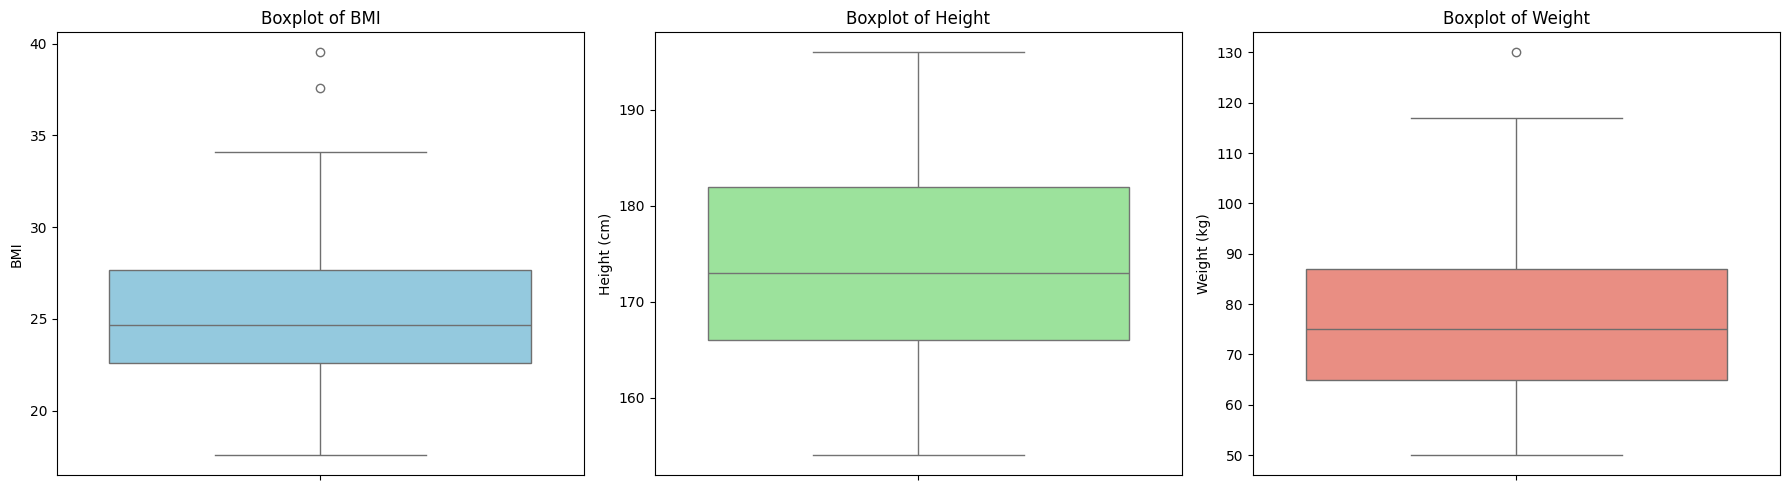

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(ax=axes[0], y=df["BMI"], color="skyblue")
axes[0].set_title("Boxplot of BMI")
axes[0].set_ylabel("BMI")

sns.boxplot(ax=axes[1], y=df["height"], color="lightgreen")
axes[1].set_title("Boxplot of Height")
axes[1].set_ylabel("Height (cm)")

sns.boxplot(ax=axes[2], y=df["weight"], color="salmon")
axes[2].set_title("Boxplot of Weight")
axes[2].set_ylabel("Weight (kg)")

plt.tight_layout()
plt.show()

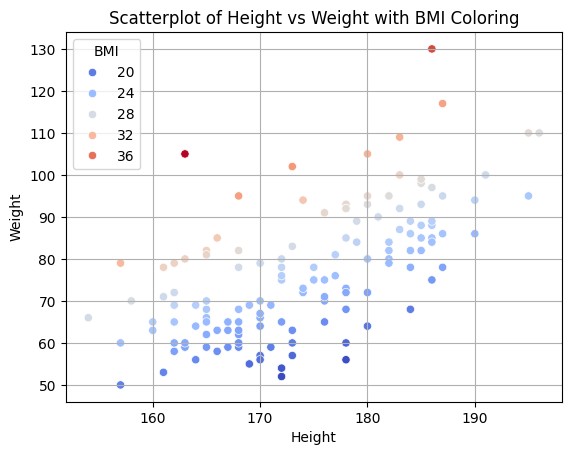

In [87]:
sns.scatterplot(x=df["height"], y=df["weight"], hue=df["BMI"], palette="coolwarm")
plt.title("Scatterplot of Height vs Weight with BMI Coloring")
plt.xlabel("Height")
plt.ylabel("Weight")
plt.grid(True)
plt.show()


In [97]:
def detect_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return data[(data < lower_bound) | (data > upper_bound)]


outliers_bmi = detect_outliers_iqr(df["BMI"])
outliers_height = detect_outliers_iqr(df["height"])
outliers_weight = detect_outliers_iqr(df["weight"])

print("BMI Outliers:", outliers_bmi, end="\n\n", sep="\n")
print("Height Outliers:", outliers_height, end="\n\n", sep="\n")
print("Weight Outliers:", outliers_weight, end="\n\n", sep="\n")


BMI Outliers:
73     37.58
144    39.52
Name: BMI, dtype: float64

Height Outliers:
Series([], Name: height, dtype: int64)

Weight Outliers:
73    130
Name: weight, dtype: int64



In [98]:
from scipy.stats import zscore

df["BMI_zscore"] = zscore(df["BMI"])
df["height_zscore"] = zscore(df["height"])
df["weight_zscore"] = zscore(df["weight"])

bmi_outliers_z = df[df["BMI_zscore"].abs() > 3]
height_outliers_z = df[df["height_zscore"].abs() > 3]
weight_outliers_z = df[df["weight_zscore"].abs() > 3]

print("BMI Outliers (Z-score):", bmi_outliers_z, end="\n\n", sep="\n")
print("Height Outliers (Z-score):", height_outliers_z,  end="\n\n", sep="\n")
print("Weight Outliers (Z-score):", weight_outliers_z,  end="\n\n", sep="\n")

BMI Outliers (Z-score):
     height  weight  gender  urbanity  fastfood    BMI  BMI_zscore  \
73      186     130       1         4      78.2  37.58    3.229085   
144     163     105       0         3       0.0  39.52    3.737069   

     height_zscore  weight_zscore  
73        1.301244       3.514314  
144      -1.172900       1.864775  

Height Outliers (Z-score):
Empty DataFrame
Columns: [height, weight, gender, urbanity, fastfood, BMI, BMI_zscore, height_zscore, weight_zscore]
Index: []

Weight Outliers (Z-score):
    height  weight  gender  urbanity  fastfood    BMI  BMI_zscore  \
73     186     130       1         4      78.2  37.58    3.229085   

    height_zscore  weight_zscore  
73       1.301244       3.514314  




### b) Handling Outliers

- Decide how to handle detected outliers (e.g., keep, remove, or correct).
- Justify your approach and show the effect on the dataset.



*Retaining the Data:*

These outlier values are real measurements that show the true diversity in the population. Removing or changing them could cause us to lose important information, especially when studying obesity, where extreme values matter. By keeping all the data, our analysis and prediction models will better reflect real-world conditions.

## 3. Bivariate Exploratory Data Analysis (EDA)

### a) BMI and Fast Food Consumption

- Create a scatter plot of BMI vs. fast food consumption.
- Calculate and interpret the correlation coefficient.
- Comment on any patterns or associations observed.

In [105]:
# before finding the correlation, let's check the fastfood consumption outliers
print("Fastfood all values:", df["fastfood"].unique(), end="\n\n", sep="\n")
fastfood_outliers = detect_outliers_iqr(df["fastfood"])
print("Fastfood Outliers:", fastfood_outliers, end="\n\n", sep="\n")

Fastfood all values:
[ 24.    6.    1.    0.   78.2 365.  182.5]

Fastfood Outliers:
26      78.2
38      78.2
48     365.0
50      78.2
63      78.2
73      78.2
101     78.2
103     78.2
105     78.2
120     78.2
124    182.5
127     78.2
131     78.2
132     78.2
141    182.5
Name: fastfood, dtype: float64



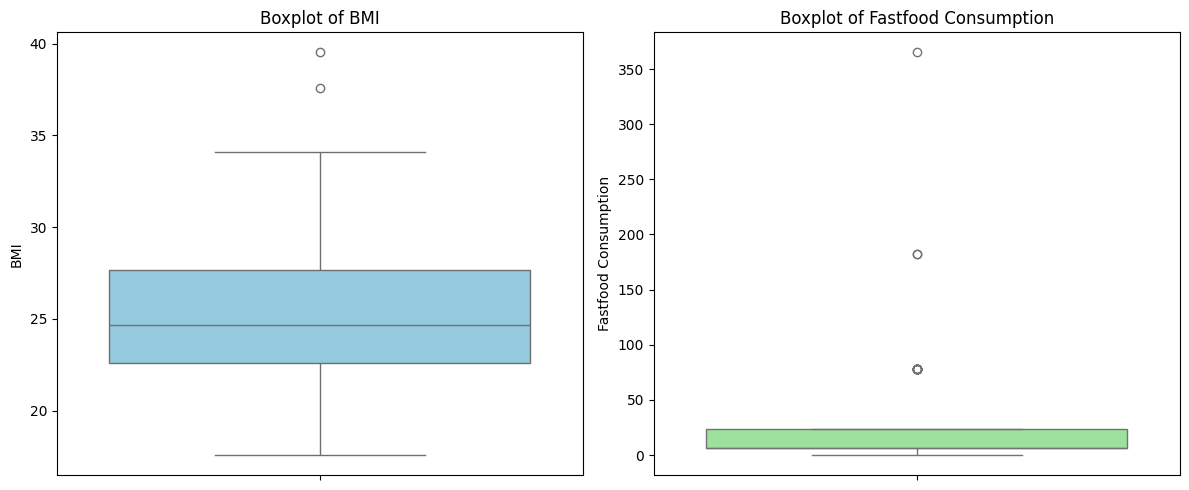

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(ax=axes[0], y=df["BMI"], color="skyblue")
axes[0].set_title("Boxplot of BMI")
axes[0].set_ylabel("BMI")

sns.boxplot(ax=axes[1], y=df["fastfood"], color="lightgreen")
axes[1].set_title("Boxplot of Fastfood Consumption")
axes[1].set_ylabel("Fastfood Consumption")

plt.tight_layout()
plt.show()

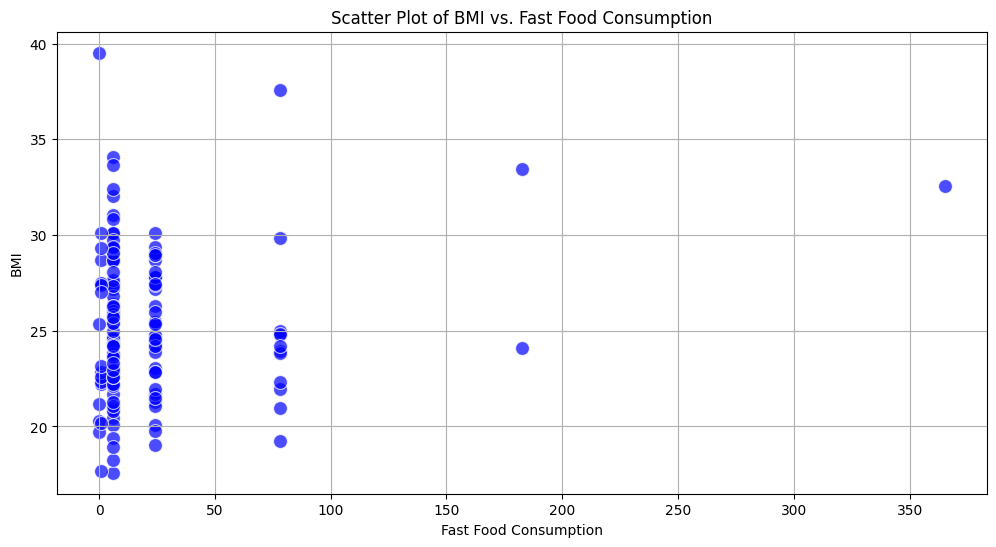

In [100]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='fastfood', y='BMI', s=100, color='blue', alpha=0.7)

plt.title("Scatter Plot of BMI vs. Fast Food Consumption")
plt.xlabel("Fast Food Consumption")
plt.ylabel("BMI")
plt.grid(True)
plt.show()

In [101]:
correlation_coef = df['BMI'].corr(df['fastfood'])
print("Correlation Coefficient (BMI vs. Fast Food):", correlation_coef)

Correlation Coefficient (BMI vs. Fast Food): 0.15322949179954135


## *Data Interpretation:*

- A correlation coefficient of 0.1532 indicates a very weak positive relationship between fast food consumption and BMI. This means that as fast food consumption increases, BMI tends to increase slightly, but the relationship is extremely weak.
- The scatter plot shows that most observations are concentrated in the area with low fast food values (close to zero), and BMI values range roughly from 18 to 30. This suggests that the majority of study participants do not consume fast food frequently.
- The presence of a few outliers with very high fast food values (up to 365 or more) does not significantly affect the overall trend, as they represent only a small portion of the sample.

*Overall Conclusion:*
In this dataset, there is a weak positive relationship between fast food consumption and BMI, indicating that an increase in fast food consumption is associated with only a slight increase in BMI. This suggests that, besides fast food, other factors—such as overall diet, physical activity, genetics, and lifestyle—likely also influence BMI.


### b) BMI by Gender

- Use boxplots or violin plots to compare BMI distributions between genders.
- Test for significant differences (e.g., t-test or Mann-Whitney U test).

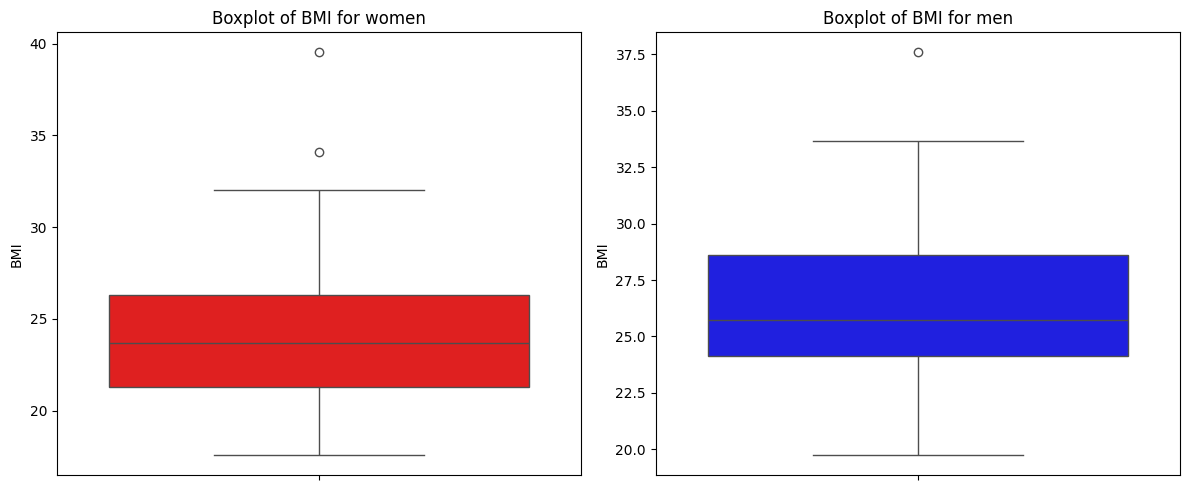

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(ax=axes[0], y=df_women["BMI"], color="red")
axes[0].set_title("Boxplot of BMI for women")
axes[0].set_ylabel("BMI")

sns.boxplot(ax=axes[1], y=df_men["BMI"], color="blue")
axes[1].set_title("Boxplot of BMI for men")
axes[1].set_ylabel("BMI")

plt.tight_layout()
plt.show()

In [111]:
from scipy.stats import ttest_ind, mannwhitneyu

# Independent samples t-test:
# We use equal_var=False to not assume equal variances.
t_stat, p_val = ttest_ind(df_men['BMI'], df_women['BMI'], equal_var=False)
print("Independent Samples T-test:")
print("T-statistic:", t_stat)
print("P-value:", p_val)

# Mann-Whitney U test:
# This non-parametric test does not assume normality.
u_stat, p_val_u = mannwhitneyu(df_men['BMI'], df_women['BMI'], alternative='two-sided')
print("\nMann-Whitney U Test:")
print("U statistic:", u_stat)
print("P-value:", p_val_u)


Independent Samples T-test:
T-statistic: 3.3248709032119357
P-value: 0.001135087409913268

Mann-Whitney U Test:
U statistic: 3554.5
P-value: 0.00025033751019184336


## *Key takeaways*

1. *Statistical Significance of Differences:*  
   - *T-test:* The t-statistic is 3.32 and the p-value is 0.0011, indicating statistically significant differences between the groups.
   - *Mann–Whitney U Test:* The U statistic is 3554.5 and the p-value is 0.00025, which also confirms significant differences in the BMI distribution between men and women.

2. *Comparison of Distributions:*  
   - The boxplot shows that the median BMI for men (around 26) is slightly higher than for women (around 25).
   - The interquartile ranges (IQR) for both men and women are comparable; however, the female group exhibits more pronounced outliers (with several values well above the overall range), while the male group has fewer outliers.

3. *Overall Interpretation:* 
   These findings indicate that the differences in BMI between men and women are statistically significant. Although the differences in medians are not very large, the tests confirm that men tend to have slightly higher BMI values compared to women. The boxplot visualization corroborates these findings, showing similar overall distributions with a few outliers, particularly in the female group.

Thus, the analysis confirms the presence of a weak yet statistically significant difference in the BMI distribution between genders.


### c) BMI by Urbanity

- Visualize BMI across different urbanity categories using boxplots or bar plots.
- Discuss any differences or trends.

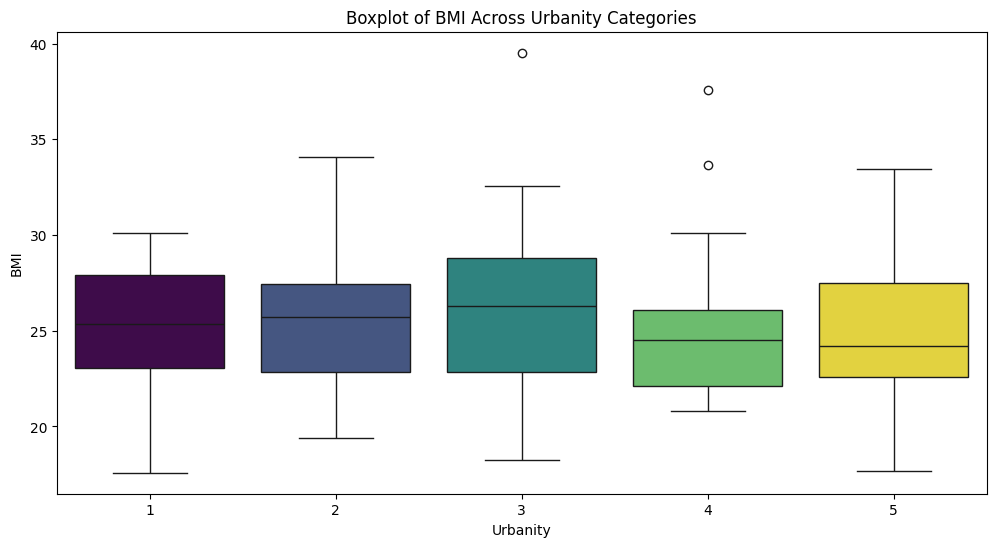

In [116]:
plt.figure(figsize=(12, 6))
ax = sns.boxplot(
    data=df,
    x='urbanity',
    y='BMI',
    hue='urbanity',    # Assign urbanity to hue to address the palette warning
    palette='viridis'
)
# Remove the legend to avoid displaying duplicate information
ax.get_legend().remove()

plt.title("Boxplot of BMI Across Urbanity Categories")
plt.xlabel("Urbanity")
plt.ylabel("BMI")
plt.show()

In [117]:
from scipy.stats import f_oneway
from scipy.stats import kruskal

groups = [group['BMI'].values for name, group in df.groupby('urbanity')]
f_stat, p_value = f_oneway(*groups)
print("ANOVA p-value:", p_value)

h_stat, p_value_kw = kruskal(*groups)
print("Kruskal-Wallis p-value:", p_value_kw)


ANOVA p-value: 0.5867049835333067
Kruskal-Wallis p-value: 0.528883103864765


## *Key takeaways*

1. *No Statistically Significant Differences:*
   - The results of the ANOVA (p = 0.5867) and the Kruskal–Wallis test (p = 0.5289) indicate that there are no statistically significant differences between the urbanity groups. In other words, the mean and median BMI values do not differ significantly across different urbanity categories.

2. *Boxplot Analysis:*
   - The boxplot shows that the median BMI values for all urbanity categories are at comparable levels, and the variation (interquartile ranges and overall range) is similar among the groups.
   - Although there are some outliers, they do not have a significant impact on the overall trend of the data.

3. *Overall Conclusion:* 
   Based on the graphical representation and the statistical tests performed, we can conclude that the level of urbanity (i.e., the degree of urbanization) in this dataset does not have a significant impact on the BMI distribution. This means that differences in urban environmental conditions, as represented by the urbanity variable, do not lead to significant changes in body weight among the study participants.

Thus, both the graphs and the p-values confirm that the variations in BMI between the urbanity groups are not statistically significant.

### d) Additional Bivariate Relationships

- Explore other pairs of variables as relevant (e.g., weight vs. height, fast food vs. gender).
- Use appropriate plots and statistics.

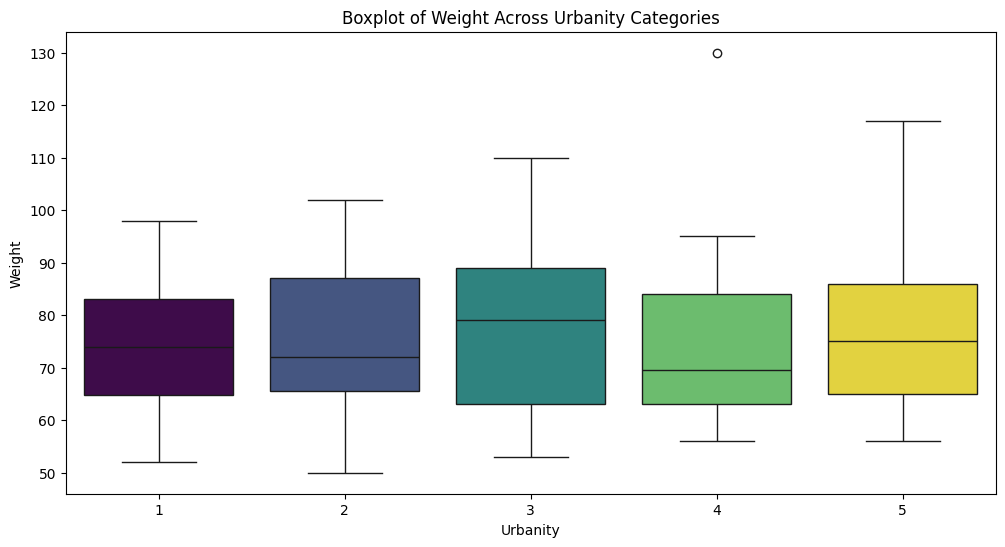

In [118]:
plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=df, x='urbanity', y='weight', hue='urbanity', palette='viridis')
ax.get_legend().remove() 

plt.title("Boxplot of Weight Across Urbanity Categories")
plt.xlabel("Urbanity")
plt.ylabel("Weight")
plt.show()

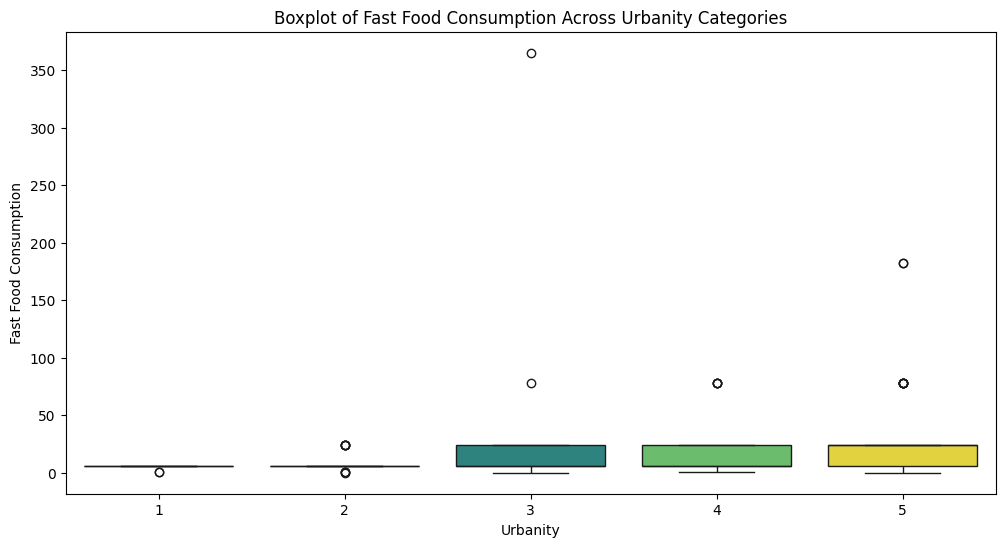

In [119]:
plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=df, x='urbanity', y='fastfood', hue='urbanity', palette='viridis')
ax.get_legend().remove()  
plt.title("Boxplot of Fast Food Consumption Across Urbanity Categories")
plt.xlabel("Urbanity")
plt.ylabel("Fast Food Consumption")
plt.show()

## *Key takeaways*

There is a clear difference in fast food consumption between less urbanized (categories 1 and 2) and more urbanized (categories 3, 4, 5) areas. This may indicate that urbanization influences access and, consequently, fast food consumption.

Thus, the chart demonstrates that urbanity categories are directly related to fast food consumption, with more urbanized areas showing higher consumption, aside from some extreme values.


## 4. Summary

- Summarize the key findings from your missing value analysis, outlier handling, and bivariate EDA.
- Discuss how these steps improve the quality and reliability of your subsequent analyses.

## General Conclusions

1. **BMI vs. Fast Food Consumption:**  
   - The Pearson correlation coefficient between BMI and fast food consumption is 0.1532, which indicates a weak positive relationship. In practical terms, an increase in fast food consumption is associated with only a slight rise in BMI, implying that this factor alone does not strongly drive changes in BMI.

2. **Gender Differences in BMI:**  
   - Both the independent samples t-test (p ≈ 0.0011) and the Mann–Whitney U test (p ≈ 0.00025) show statistically significant differences between men and women. Visualizations suggest that men tend to have a slightly higher BMI than women, though the difference is moderate. This highlights gender as one contributing factor to variations in BMI.

3. **Impact of Urbanity:**  
   - **On BMI:** The results of ANOVA (p ≈ 0.5867) and the Kruskal–Wallis test (p ≈ 0.5289) indicate that BMI does not differ significantly across different urbanity categories. Thus, in this dataset, urbanization per se does not have a direct, marked influence on BMI.
   - **On Fast Food Consumption:** The boxplots reveal a distinct pattern in fast food consumption: in less urbanized areas (categories 1 and 2), consumption is virtually zero, whereas in more urbanized areas (categories 3, 4, and 5) consumption ranges from 0 to 24 (with one outlier). This suggests that more urbanized areas likely offer greater access to fast food, which in turn could have an indirect effect on BMI.

4. **Overall Interpretation:**  
   - The dataset indicates that BMI is influenced by multiple factors. While fast food consumption and gender show moderate to weak associations with BMI, urbanity does not directly impact BMI although it affects the availability and consumption of fast food.
   - The interplay of these factors highlights the complex and multifactorial nature of BMI regulation. No single factor completely explains BMI variability, emphasizing the need for a holistic approach when analyzing body weight and related health outcomes.
